In [2]:
import pickle
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

In [10]:
with open("../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

For LSST Y10 sample we make multiple cuts on dissimilarity.

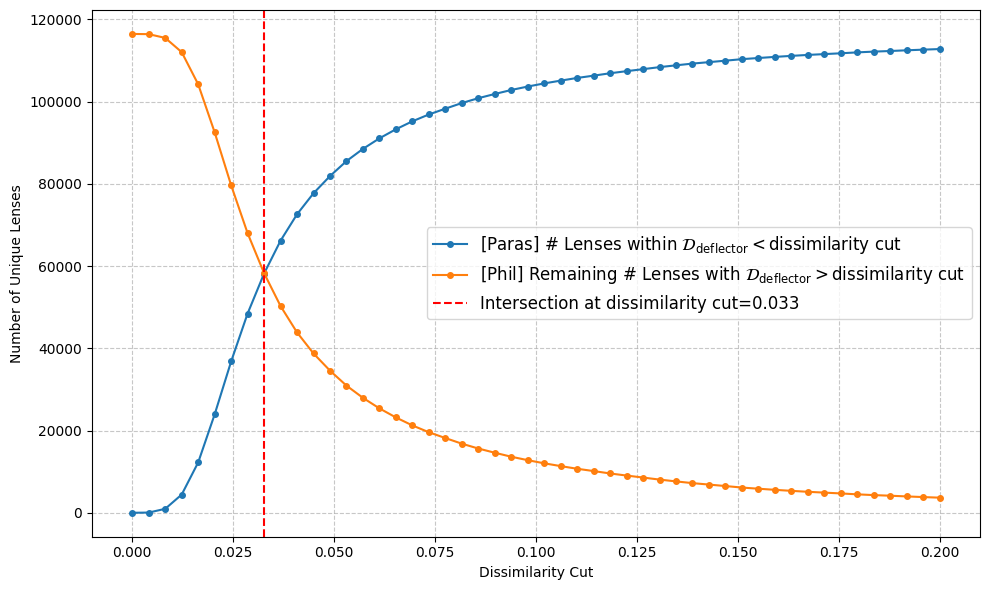

In [12]:
# 0. Setup: Define inputs
sample_key = 'lsst_y10'
pairs_table_with_errors = pdspl_samples[sample_key]['pairs_analysis']['pairs_table_with_errors']
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

# 1. Define the range of dissimilarity cuts to test
dissimilarity_cuts = np.linspace(0, 0.2, 50)

# List to store the number of unique lenses for each cut
unique_lenses_counts = []

# 2. Loop through each cut and apply your logic
for cut in dissimilarity_cuts:
    # Find lenses not paired within the current cut
    pairs_table_with_dissimilarity_cut = pairs_table_with_errors[pairs_table_with_errors['dissimilarity'] > cut]
    
    indices_1 = np.array(pairs_table_with_dissimilarity_cut['index_1'])
    indices_2 = np.array(pairs_table_with_dissimilarity_cut['index_2'])
    
    # Concatenate and find unique
    all_indices = np.concatenate([indices_1, indices_2])
    unique_indices = np.unique(all_indices)
    
    # Store the count of unique lenses
    unique_lenses_counts.append(len(unique_indices))

# numpy array for plotting
unique_lenses_counts = np.array(unique_lenses_counts)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dissimilarity_cuts, unique_lenses_counts[0] - unique_lenses_counts, marker='o', linestyle='-', markersize=4, 
         label='[Paras] # Lenses within $\\mathcal{D}_{\\rm deflector} < $dissimilarity cut')
plt.plot(dissimilarity_cuts, unique_lenses_counts, marker='o', linestyle='-', markersize=4, label='[Phil] Remaining # Lenses with $\\mathcal{D}_{\\rm deflector} > $dissimilarity cut')

# make a vertical line where the two curves intersect
intersection_index = np.argmin(np.abs(unique_lenses_counts[0] - 2*unique_lenses_counts))
plt.axvline(x=dissimilarity_cuts[intersection_index], color='red', linestyle='--', label=f'Intersection at dissimilarity cut={dissimilarity_cuts[intersection_index]:.3f}')

plt.xlabel('Dissimilarity Cut')
plt.ylabel('Number of Unique Lenses')
# plt.title('Number of Unique Lenses vs. Dissimilarity Cut')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(fontsize=12)

plt.show()

In [13]:

# 0. Setup: Define inputs
sample_key = 'lsst_y10'
table = pdspl_samples[sample_key]['table']
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

pairing_keys = pdspl_samples[sample_key]['pairing_keys']
dissimilarity_keys = pdspl_samples[sample_key]['dissimilarity_keys']
dissimilarity_cuts = [0.025, 0.033, 0.05]

pairs_table_err = pdspl_samples[sample_key]['pairs_analysis']['pairs_table_with_errors']

# 5. Extract Unique Lens IDs for each cut
lens_ids_dict = {}
num_pairs_dict = {}

for cut in dissimilarity_cuts:
    # Filter for pairs where dissimilarity is GREATER than the cut
    mask_gt_cut = pairs_table_err['dissimilarity'] > cut
    filtered_pairs = pairs_table_err[mask_gt_cut]

    total_pairs = len(pairs_table_err)
    num_pairs = len(filtered_pairs)
    num_pairs_dict[f'dissimilarity_cut_leq_{cut:.3f}'] = total_pairs - num_pairs
    num_pairs_dict[f'dissimilarity_cut_gt_{cut:.3f}'] = num_pairs
    
    # Get all unique indices involved in these bad pairs
    indices_1 = filtered_pairs['index_1']
    indices_2 = filtered_pairs['index_2']
    unique_indices = np.unique(np.concatenate([indices_1, indices_2]))
    
    # Map indices back to the original lens_ids from the base table
    unique_lens_ids = table['lens_id'][unique_indices]
    
    # Store in dictionary
    dict_key = f'dissimilarity_cut_gt_{cut:.3f}'
    lens_ids_dict[dict_key] = unique_lens_ids

    # now also save the complement set of good lenses for this cut
    lens_ids_complement = np.setdiff1d(table['lens_id'], unique_lens_ids)
    dict_key_complement = f'dissimilarity_cut_leq_{cut:.3f}'
    lens_ids_dict[dict_key_complement] = lens_ids_complement


# Print a quick summary of how many lenses were found
for k, v in lens_ids_dict.items():
    print(f"{k}: {len(v)} unique lenses found.")

# save pickle of lens_ids_dict
with open(f'lens_ids_dict_{sample_key}.pkl', 'wb') as f:
    pickle.dump(lens_ids_dict, f)

dissimilarity_cut_gt_0.025: 78110 unique lenses found.
dissimilarity_cut_leq_0.025: 38361 unique lenses found.
dissimilarity_cut_gt_0.033: 57511 unique lenses found.
dissimilarity_cut_leq_0.033: 58960 unique lenses found.
dissimilarity_cut_gt_0.050: 33658 unique lenses found.
dissimilarity_cut_leq_0.050: 82813 unique lenses found.


In [ ]:
lsst_y10_GGLs_table = Table.read(
    "../../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
)

# load pickle of lens_ids_dict
with open(f'lens_ids_dict_{sample_key}.pkl', 'rb') as f:
    loaded_lens_ids_dict = pickle.load(f)

# The pickle file has following structure:
# {
#     'dissimilarity_cut_gt_0.025': array([lens_id_...]),   # 78110 unique lenses for Phil
#     'dissimilarity_cut_leq_0.025': array([lens_id_...]),  # 38361 unique lenses ==> 34072 lens pairs for Paras

#     'dissimilarity_cut_gt_0.033': array([lens_id_...]),   # 57511 unique lenses for Phil
#     'dissimilarity_cut_leq_0.033': array([lens_id_...]),  # 58960 unique lenses ==> 48963 lens pairs for Paras

#     'dissimilarity_cut_gt_0.050': array([lens_id_...]),   # 33658 unique lenses for Phil
#     'dissimilarity_cut_leq_0.050': array([lens_id_...]),  # 82813 unique lenses ==> 64956 lens pairs for Paras
# }

# example to choose lenses with dissimilarity cut greater than 0.033
lsst_y10_GGLs_table_dissimilarity_cut_gt_0_033 = lsst_y10_GGLs_table[np.isin(lsst_y10_GGLs_table['lens_id'], loaded_lens_ids_dict['dissimilarity_cut_gt_0.033'])]